<a href="https://colab.research.google.com/github/hjkim0895-beep/Python_Programming/blob/main/%5B%EA%B9%80%ED%83%9C%ED%98%B8%5D_%5B2026122970%5D_%EA%B8%B0%EB%A7%90%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# 라이브러리 설치
!pip install beautifulsoup4 -q
!apt-get install -y fonts-nanum -q

# 런타임 재시작 없이 폰트 캐시 강제 갱신
import matplotlib as mpl
mpl.font_manager._load_fontmanager(try_read_cache=False)

# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

# 나눔고딕 폰트 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('완료')
print('적용 폰트:', plt.rcParams['font.family'])

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
완료
적용 폰트: ['NanumGothic']


In [22]:
# 코랩에서 파일 업로드
from google.colab import files
uploaded = files.upload()
# 여기서 두 파일 모두 업로드:
# KOBIS_연도별박스오피스_2026-06-19.xls (2019년)
# KOBIS_연도별박스오피스_2026-06-19-1.xls (2023년)

Saving KOBIS_연도별박스오피스_2026-06-20 (1).xls to KOBIS_연도별박스오피스_2026-06-20 (1) (2).xls
Saving KOBIS_연도별박스오피스_2026-06-20.xls to KOBIS_연도별박스오피스_2026-06-20 (3).xls


In [23]:
import os
print(os.listdir('/content'))

['.config', '시각화1_국적별비율.png', 'KOBIS_연도별박스오피스_2026-06-20.xls', 'KOBIS_연도별박스오피스_2026-06-20 (1) (1).xls', 'KOBIS_연도별박스오피스_2026-06-20 (2).xls', 'KOBIS_연도별박스오피스_2026-06-20 (3).xls', '시각화2_관객수증감.png', 'KOBIS_연도별박스오피스_2026-06-20 (1) (2).xls', 'KOBIS_연도별박스오피스_2026-06-20 (1).xls', 'sample_data']


In [24]:
# KOBIS HTML형식 xls 파일을 읽는 함수
# KOBIS 다운로드 파일은 .xls 확장자이지만 실제로는 HTML 형식이므로
# pandas read_excel()이 아닌 BeautifulSoup HTML 파싱 방식을 사용한다
def read_kobis(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')

    # 페이지 내 두 번째 테이블이 실제 데이터 테이블
    tables = soup.find_all('table')
    rows = tables[1].find_all('tr')

    # 첫 번째 행: 헤더(컬럼명) 추출
    headers = [th.get_text(strip=True) for th in rows[0].find_all(['th', 'td'])]

    # 나머지 행: 데이터 추출 (컬럼 수가 맞는 행만)
    data = []
    for row in rows[1:]:
        cells = [td.get_text(strip=True) for td in row.find_all('td')]
        if cells and len(cells) == len(headers):
            data.append(cells)

    return pd.DataFrame(data, columns=headers)

# 파일명 설정 (업로드한 파일명과 동일하게)
FILE_2019 = 'KOBIS_연도별박스오피스_2026-06-20.xls'
FILE_2023 = 'KOBIS_연도별박스오피스_2026-06-20 (1).xls'

# 데이터 적재
df_2019_raw = read_kobis(FILE_2019)
df_2023_raw = read_kobis(FILE_2023)

# 적재 결과 확인
print('=== 2019년 데이터 ===')
print(f'행 수: {len(df_2019_raw)}, 컬럼 수: {len(df_2019_raw.columns)}')
print('컬럼:', df_2019_raw.columns.tolist())
print(df_2019_raw.head(3))

print('\n=== 2023년 데이터 ===')
print(f'행 수: {len(df_2023_raw)}, 컬럼 수: {len(df_2023_raw.columns)}')
print(df_2023_raw.head(3))

=== 2019년 데이터 ===
행 수: 4890, 컬럼 수: 11
컬럼: ['순위', '영화명', '개봉일', '매출액', '매출액 점유율', '관객수', '스크린수', '상영횟수', '대표국적', '국적', '배급사']
  순위         영화명         개봉일           매출액               매출액 점유율       관객수  \
0  1        극한직업  2019-01-23  139651845516                 0.073  16265618   
1  2  어벤져스: 엔드게임  2019-04-24  122181161160                 0.064  13934399   
2  3      겨울왕국 2  2019-11-21  111596248720  0.057999999999999996  13369064   

   스크린수    상영횟수 대표국적  국적                 배급사  
0  2003  292584   한국  한국           (주)씨제이이엔엠  
1  2835  241979   미국  미국  월트디즈니컴퍼니코리아 유한책임회사  
2  2648  282557   미국  미국  월트디즈니컴퍼니코리아 유한책임회사  

=== 2023년 데이터 ===
행 수: 4368, 컬럼 수: 11
  순위    영화명         개봉일           매출액               매출액 점유율       관객수  스크린수  \
0  1  서울의 봄  2023-11-22  115350491410                 0.091  11854779  2463   
1  2  범죄도시3  2023-05-31  104687737771                 0.083  10682813  2582   
2  3   엘리멘탈  2023-06-14   71120500040  0.055999999999999994   7238453  1664   

     상영횟수 대표국적  국적

In [25]:
# 전처리 함수 정의
def preprocess(df, year):
    df = df.copy()
    print(f'=== {year}년 전처리 ===')
    print(f'전처리 전: {len(df)}행')

    # 1. 영화명 앞뒤 공백 제거
    # 공백이 있으면 이후 집합 연산에서 동일 영화를 다른 항목으로 인식함
    df['영화명'] = df['영화명'].str.strip()

    # 2. 합계 행 제거
    # str.contains('합계') 방식은 빈 문자열 합계 행을 잡지 못해
    # pd.to_numeric으로 숫자가 아닌 행을 NaN 처리 후 제거하는 방식 사용
    df = df[pd.to_numeric(df['순위'], errors='coerce').notna()]
    print(f'합계 행 제거 후: {len(df)}행')

    # 3. 중복 행 제거
    # 동일 행이 두 번 이상 존재하면 관객수 집계 시 이중 합산 발생
    before_dup = len(df)
    df = df.drop_duplicates()
    print(f'중복 제거 후: {len(df)}행 ({before_dup - len(df)}행 제거)')

    # 4. 수치형 컬럼 자료형 변환
    # BeautifulSoup 파싱 결과 모든 컬럼이 str로 읽힘
    # 쉼표(,) 제거 후 pd.to_numeric으로 변환, 실패 시 NaN 처리
    for col in ['관객수', '매출액', '스크린수', '상영횟수']:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].str.replace(',', ''),
                errors='coerce'  # 변환 불가 값은 NaN으로 처리 (오류 방지)
            )

    # 5. 핵심 컬럼 결측값 제거
    # subset 지정으로 다른 컬럼 결측값은 허용 (불필요한 데이터 손실 방지)
    before_na = len(df)
    df = df.dropna(subset=['영화명', '관객수'])
    print(f'결측값 제거 후: {len(df)}행 ({before_na - len(df)}행 제거)')
    print(f'최종 전처리 후: {len(df)}행\n')

    return df.reset_index(drop=True)

# 전처리 실행
df_2019 = preprocess(df_2019_raw, 2019)
df_2023 = preprocess(df_2023_raw, 2023)

# 자료형 확인
print('=== 전처리 후 자료형 확인 ===')
print(df_2019[['관객수', '매출액', '스크린수']].dtypes)

=== 2019년 전처리 ===
전처리 전: 4890행
합계 행 제거 후: 4889행
중복 제거 후: 4889행 (0행 제거)
결측값 제거 후: 4889행 (0행 제거)
최종 전처리 후: 4889행

=== 2023년 전처리 ===
전처리 전: 4368행
합계 행 제거 후: 4367행
중복 제거 후: 4367행 (0행 제거)
결측값 제거 후: 4367행 (0행 제거)
최종 전처리 후: 4367행

=== 전처리 후 자료형 확인 ===
관객수     int64
매출액     int64
스크린수    int64
dtype: object


In [26]:
# 문항 1: 두 시점 영화명 집합 생성 및 차집합 연산
set_2019 = set(df_2019['영화명'])
set_2023 = set(df_2023['영화명'])

# 차집합: 한쪽 시점에만 존재하는 영화 추출
only_in_2019 = set_2019 - set_2023  # 2019년에만 있는 영화
only_in_2023 = set_2023 - set_2019  # 2023년에만 있는 영화

print(f'2019년 전체 상영 영화 수: {len(set_2019)}편')
print(f'2023년 전체 상영 영화 수: {len(set_2023)}편')
print(f'\n2019년에만 있는 영화 수: {len(only_in_2019)}편')
print(f'2023년에만 있는 영화 수: {len(only_in_2023)}편')
print('\n[2019년에만 있는 영화 예시 20편]')
print(sorted(list(only_in_2019))[:20])
print('\n[2023년에만 있는 영화 예시 20편]')
print(sorted(list(only_in_2023))[:20])

2019년 전체 상영 영화 수: 4841편
2023년 전체 상영 영화 수: 4336편

2019년에만 있는 영화 수: 4044편
2023년에만 있는 영화 수: 3539편

[2019년에만 있는 영화 예시 20편]
['(2019최강애니전) 감각의 빛', '(2019최강애니전) 감성의 온도', '(2019최강애니전) 감흥의 순간', '(2019최강애니전) 꿈의 놀이터', '(2019최강애니전) 상상의 도발', '(2019최강애니전) 소녀이야기', '(2019최강애니전) 환상의 언어', '0.0MHz', '007 제2편 : 위기일발', '10 미니츠 곤', '10 바이 10', '10thDMZDocs앵콜전_다큐패밀리 단편', '10thDMZDocs앵콜전_청소년 경쟁 단편', '10년', '10월 단편 상상극장-제13회 대단한 단편영화제 수상작', '10월 수요단편극장- To infinity and beyond!', '10월단단한영화展(윤가은 감독전)', '10회 대구사회복지영화제 단편극 1', '10회 대구사회복지영화제 단편극 2', '10회 대구사회복지영화제 단편극 3']

[2023년에만 있는 영화 예시 20편]
['#Take No. 고백(인디스데이)', '08월 수요단편극장: 감각하고 연결되고 확장하는, 여성의 몸이 가진 무한한 서사', '10월 프레임워크 - 케네스 앵거, 매직 랜턴 사이클: 파트 2', '10일간의 애인', '11', '11월 수요단편극장 - 올해의 이슈작', '12월 수요단편극장 - 올해를 빛낸 배우전', '12월 수요단편극장: 2022, 불안의 시대를 헤쳐 온 청춘의 얼굴들 - 신가환X박가영X윤혜리X유이든', '12월 프레임워크 - 스탠 반더빅 작품선', '13 미닛츠', '14회 광주여성영화제 귄 당선작 1', '14회 광주여성영화제 귄 당선작 2', '14회 광주여성영화제 귄 당선작 3', '14회 광주여성영화제 메이드 인 광주', '14회 광주여성영화제 선을넘는: 단편초청', '14회 광주여성영화제 아시아 여성의 오늘: 단편초청',

In [27]:
# 문항 2: 관객수 기준 내림차순 정렬 후 상위 20편 추출
top20_2019 = (df_2019
              .sort_values('관객수', ascending=False)
              .head(20)
              [['순위', '영화명', '관객수', '대표국적', '배급사']]
              .reset_index(drop=True))

top20_2023 = (df_2023
              .sort_values('관객수', ascending=False)
              .head(20)
              [['순위', '영화명', '관객수', '대표국적', '배급사']]
              .reset_index(drop=True))

print('=== 2019년 관객수 상위 20편 ===')
print(top20_2019.to_string(index=False))
print('\n=== 2023년 관객수 상위 20편 ===')
print(top20_2023.to_string(index=False))

=== 2019년 관객수 상위 20편 ===
순위           영화명      관객수 대표국적                      배급사
 1          극한직업 16265618   한국                (주)씨제이이엔엠
 2    어벤져스: 엔드게임 13934399   미국       월트디즈니컴퍼니코리아 유한책임회사
 3        겨울왕국 2 13369064   미국       월트디즈니컴퍼니코리아 유한책임회사
 4           알라딘 12552283   미국       월트디즈니컴퍼니코리아 유한책임회사
 5           기생충 10085275   한국                (주)씨제이이엔엠
 6           엑시트  9426011   한국                (주)씨제이이엔엠
 7 스파이더맨: 파 프롬 홈  8021145   미국 소니픽쳐스엔터테인먼트코리아주식회사극장배급지점
 8           백두산  6290502   한국     (주)씨제이이엔엠,(주)덱스터스튜디오
 9         캡틴 마블  5802810   미국       월트디즈니컴퍼니코리아 유한책임회사
10            조커  5247874   미국            워너브러더스 코리아(주)
11        봉오동 전투  4787538   한국                   (주)쇼박스
12         라이온 킹  4743264   미국       월트디즈니컴퍼니코리아 유한책임회사
13  나쁜 녀석들: 더 무비  4573902   한국                (주)씨제이이엔엠
14      82년생 김지영  3678156   한국        롯데컬처웍스(주)롯데엔터테인먼트
15  분노의 질주: 홉스&쇼  3657536   미국      유니버설픽쳐스인터내셔널 코리아(유)
16      토이 스토리 4  3400034   미국       월트디즈니컴퍼니코리아 유한책임회사
17             돈  33891

In [28]:
# 문항 3: 상위 50편 교집합
top50_set_2019 = set(df_2019.sort_values('관객수', ascending=False).head(50)['영화명'])
top50_set_2023 = set(df_2023.sort_values('관객수', ascending=False).head(50)['영화명'])

# 교집합: 두 시점 모두 상위 50편에 포함된 영화
common_top50 = top50_set_2019 & top50_set_2023

print(f'두 시점 상위 50편 중 공통 영화 수: {len(common_top50)}편')
if len(common_top50) > 0:
    print('\n[공통 영화 목록]')
    for movie in sorted(common_top50):
        print(f'  - {movie}')
else:
    print('\n두 시점 상위 50편에 공통으로 등장하는 영화가 없음')
    print('→ 5년 사이 극장가 콘텐츠 지형이 완전히 교체되었음을 의미')

두 시점 상위 50편 중 공통 영화 수: 0편

두 시점 상위 50편에 공통으로 등장하는 영화가 없음
→ 5년 사이 극장가 콘텐츠 지형이 완전히 교체되었음을 의미


In [29]:
# 문항 4: 대표국적 기준 한국/외국 분류 후 관객수 집계
def classify_country(x):
    return '한국' if str(x).strip() == '한국' else '외국'

df_2019['국적구분'] = df_2019['대표국적'].apply(classify_country)
df_2023['국적구분'] = df_2023['대표국적'].apply(classify_country)

# groupby로 국적별 관객수 합계 집계
nat_2019 = df_2019.groupby('국적구분')['관객수'].sum()
nat_2023 = df_2023.groupby('국적구분')['관객수'].sum()

print('=== 2019년 국적별 관객수 ===')
print(nat_2019)
print(f'한국 영화 비율: {nat_2019.get("한국",0)/nat_2019.sum()*100:.2f}%')
print(f'외국 영화 비율: {nat_2019.get("외국",0)/nat_2019.sum()*100:.2f}%')

print('\n=== 2023년 국적별 관객수 ===')
print(nat_2023)
print(f'한국 영화 비율: {nat_2023.get("한국",0)/nat_2023.sum()*100:.2f}%')
print(f'외국 영화 비율: {nat_2023.get("외국",0)/nat_2023.sum()*100:.2f}%')

=== 2019년 국적별 관객수 ===
국적구분
외국    111056432
한국    115621796
Name: 관객수, dtype: int64
한국 영화 비율: 51.01%
외국 영화 비율: 48.99%

=== 2023년 국적별 관객수 ===
국적구분
외국    64384998
한국    60751267
Name: 관객수, dtype: int64
한국 영화 비율: 48.55%
외국 영화 비율: 51.45%


In [30]:
# 문항 5: 2019년 상위 20편 기준으로 2023년 관객수와 증감 비교
top20_2019_df = (df_2019
                 .sort_values('관객수', ascending=False)
                 .head(20)[['영화명', '관객수']]
                 .copy())
top20_2019_df.columns = ['영화명', '관객수_2019']

# 2023년 영화명별 관객수 합계
aud_2023 = df_2023.groupby('영화명')['관객수'].sum().reset_index()
aud_2023.columns = ['영화명', '관객수_2023']

# left join: 2019년 상위 20편 기준, 2023년에 없는 영화는 NaN → 0 처리
# inner join을 쓰면 2023년에 없는 영화가 결과에서 제외되어 의도와 달라짐
merged = top20_2019_df.merge(aud_2023, on='영화명', how='left')
merged['관객수_2023'] = merged['관객수_2023'].fillna(0).astype(int)
merged['증감'] = merged['관객수_2023'] - merged['관객수_2019']

print('=== 2019년 상위 20편 관객수 증감 ===')
print(merged[['영화명', '관객수_2019', '관객수_2023', '증감']].to_string(index=False))

increased = merged[merged['증감'] > 0]
decreased = merged[merged['증감'] <= 0]
print(f'\n증가한 영화: {len(increased)}편')
print(f'감소한 영화: {len(decreased)}편')

=== 2019년 상위 20편 관객수 증감 ===
          영화명  관객수_2019  관객수_2023        증감
         극한직업  16265618       142 -16265476
   어벤져스: 엔드게임  13934399         0 -13934399
       겨울왕국 2  13369064     21005 -13348059
          알라딘  12552283         0 -12552283
          기생충  10085275       222 -10085053
          엑시트   9426011       628  -9425383
스파이더맨: 파 프롬 홈   8021145         0  -8021145
          백두산   6290502        43  -6290459
        캡틴 마블   5802810         0  -5802810
           조커   5247874     21205  -5226669
       봉오동 전투   4787538       539  -4786999
        라이온 킹   4743264         0  -4743264
 나쁜 녀석들: 더 무비   4573902         0  -4573902
     82년생 김지영   3678156       103  -3678053
 분노의 질주: 홉스&쇼   3657536         0  -3657536
     토이 스토리 4   3400034         0  -3400034
            돈   3389123       125  -3388998
          악인전   3364712         0  -3364712
    가장 보통의 연애   2924563         0  -2924563
          말모이   2812877       189  -2812688

증가한 영화: 0편
감소한 영화: 20편


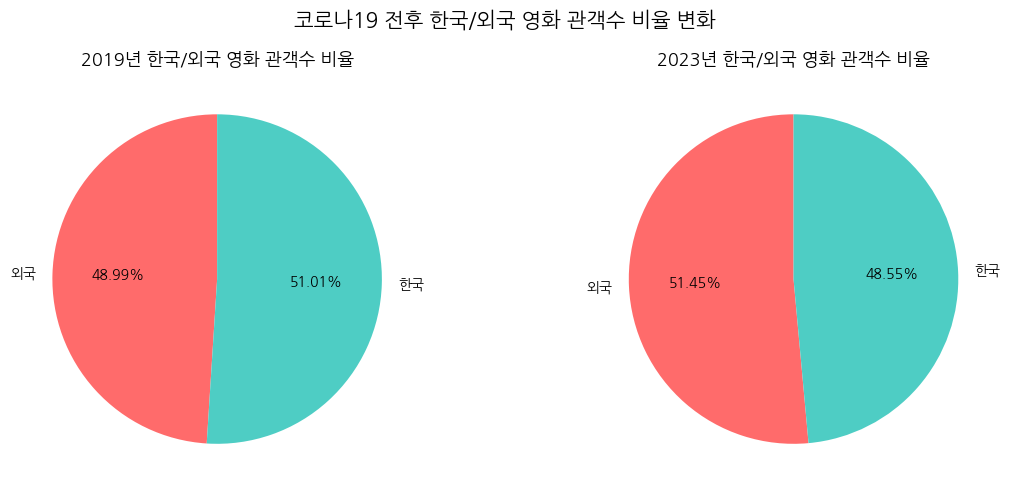

In [31]:
# 시각화 1: 국적별 관객수 비율 파이 차트
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#FF6B6B', '#4ECDC4']

axes[0].pie(nat_2019.values, labels=nat_2019.index,
            autopct='%1.2f%%', colors=colors, startangle=90)
axes[0].set_title('2019년 한국/외국 영화 관객수 비율', fontsize=13, fontweight='bold')

axes[1].pie(nat_2023.values, labels=nat_2023.index,
            autopct='%1.2f%%', colors=colors, startangle=90)
axes[1].set_title('2023년 한국/외국 영화 관객수 비율', fontsize=13, fontweight='bold')

plt.suptitle('코로나19 전후 한국/외국 영화 관객수 비율 변화', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('시각화1_국적별비율.png', dpi=150, bbox_inches='tight')
plt.show()

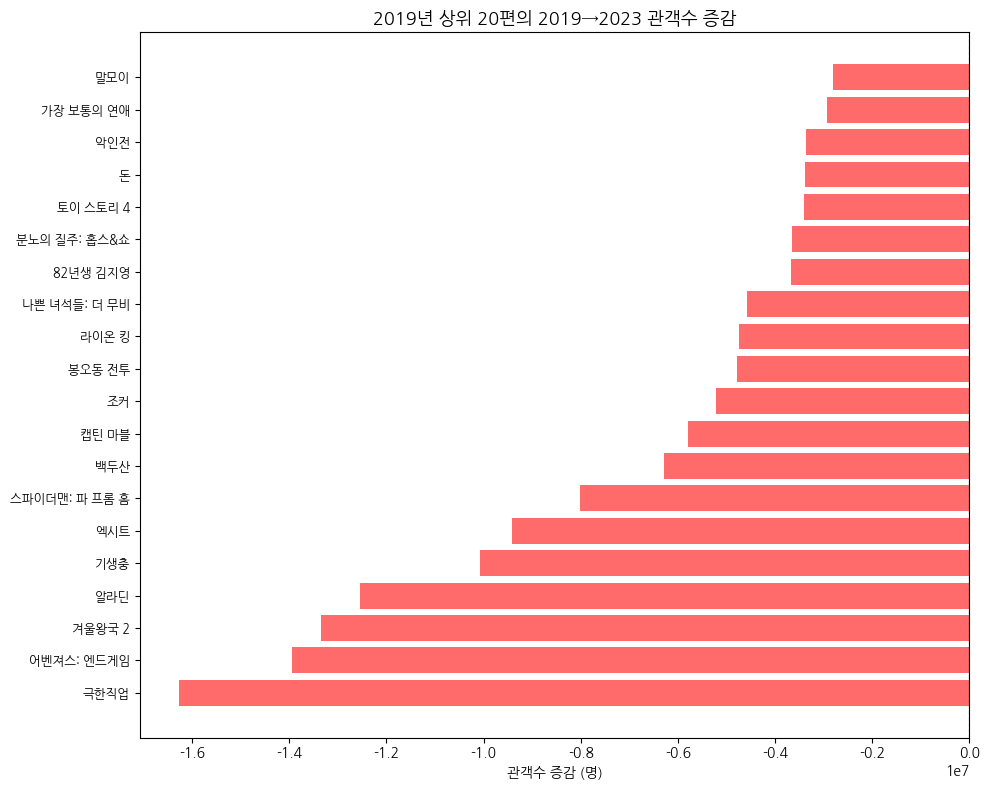

In [32]:
# 시각화 2: 관객수 증감 수평 바 차트
merged_sorted = merged.sort_values('증감', ascending=True)
colors_bar = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in merged_sorted['증감']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(merged_sorted['영화명'], merged_sorted['증감'], color=colors_bar)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('2019년 상위 20편의 2019→2023 관객수 증감', fontsize=13, fontweight='bold')
ax.set_xlabel('관객수 증감 (명)')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('시각화2_관객수증감.png', dpi=150, bbox_inches='tight')
plt.show()

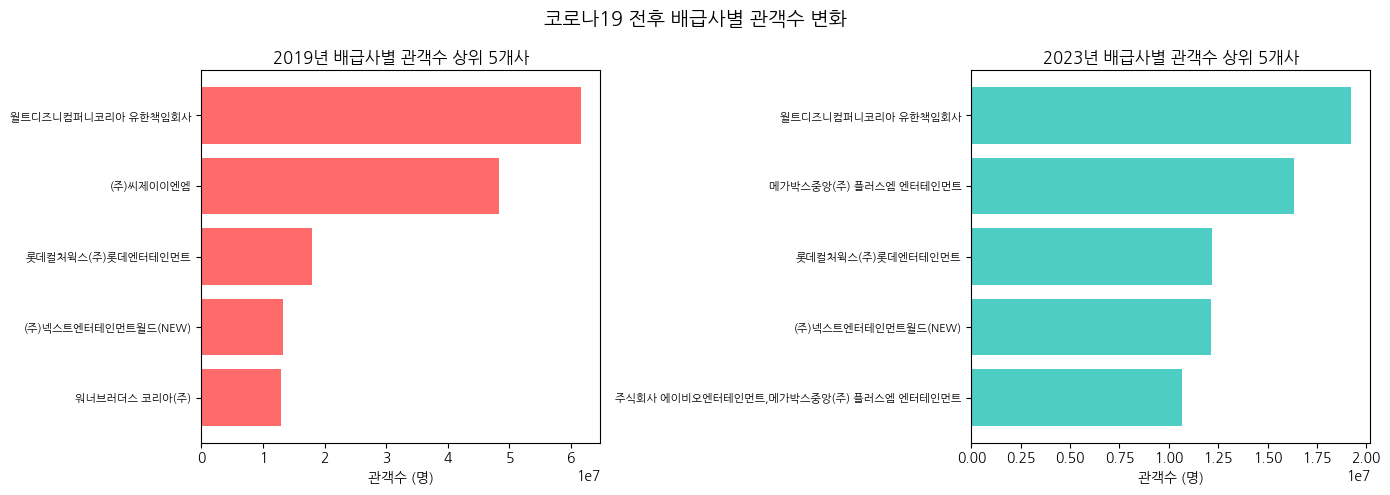

In [33]:
# 시각화 3: 배급사별 상위 5개사 관객수 비교 (추가 분석)
dist_2019 = df_2019.groupby('배급사')['관객수'].sum().sort_values(ascending=False).head(5)
dist_2023 = df_2023.groupby('배급사')['관객수'].sum().sort_values(ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(dist_2019.index[::-1], dist_2019.values[::-1], color='#FF6B6B')
axes[0].set_title('2019년 배급사별 관객수 상위 5개사', fontsize=12, fontweight='bold')
axes[0].set_xlabel('관객수 (명)')
axes[0].tick_params(axis='y', labelsize=8)

axes[1].barh(dist_2023.index[::-1], dist_2023.values[::-1], color='#4ECDC4')
axes[1].set_title('2023년 배급사별 관객수 상위 5개사', fontsize=12, fontweight='bold')
axes[1].set_xlabel('관객수 (명)')
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('코로나19 전후 배급사별 관객수 변화', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('시각화3_배급사별관객수.png', dpi=150, bbox_inches='tight')
plt.show()